# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of this experiment is to determine how different burrito ingredients — protein type, salsa type, and the inclusion of potatoes — affect customer satisfaction ratings, and to identify which ingredient combination produces the highest overall satisfaction.

2. State the outcome variable and how it was measured.

The outcome variable is **customer satisfaction rating**.

It is a **quantitative, approximately continuous variable** measured on a scale from **1 to 10**, where:

- **1 = terrible**

- **10 = amazing**

Each participant rated the burrito they received after tasting it.

3. State the independent variables. What lurking variables may be present?

The independent variables are:

- **Protein** — categorical nominal variable  

  - Bacon

  - Sausage

  - Chorizo

- **Salsa** — categorical nominal variable  

  - Mild

  - Hot

- **Potatoes** — categorical nominal variable  

  - Yes

  - No

Some possible lurking variables include:

- participant spice tolerance  

- individual food preferences  

- hunger level before tasting  

- portion size differences  

- ingredient freshness  

- prior experience with breakfast burritos  

- mood or fatigue during tasting  

- differences in how warm the burritos were served

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

A full factorial design is preferred here because the experiment includes one factor with **3 levels** (Protein), so the design is not naturally suited to a standard $2^k$ fractional factorial structure.

Using the full factorial design allows all possible treatment combinations to be tested, including all interaction effects between protein, salsa, and potatoes. Since food preferences may depend on combinations of ingredients rather than single ingredients alone, observing all treatment combinations is useful.

In this case, the total number of treatment combinations is still manageable:

$$
3 \times 2 \times 2 = 12
$$

so there is less need to reduce the design using a fractional approach.

A fractional factorial design would reduce time and cost, but some effects would become aliased, making interpretation more difficult.

5. State all sets of statistical hypotheses.

Let:

- $\mu_{Bacon}, \mu_{Sausage}, \mu_{Chorizo}$ = mean satisfaction ratings for protein types  
- $\mu_{Hot}, \mu_{Mild}$ = mean satisfaction ratings for salsa types  
- $\mu_{No}, \mu_{Yes}$ = mean satisfaction ratings for potatoes  

We test for main effects and interaction effects.

### Main effect of Protein

$$
H_0: \mu_{Bacon} = \mu_{Sausage} = \mu_{Chorizo}
$$

$$
H_A: \text{At least one protein mean differs}
$$

---

### Main effect of Salsa

$$
H_0: \mu_{Hot} = \mu_{Mild}
$$

$$
H_A: \mu_{Hot} \ne \mu_{Mild}
$$

---

### Main effect of Potatoes

$$
H_0: \mu_{No} = \mu_{Yes}
$$

$$
H_A: \mu_{No} \ne \mu_{Yes}
$$

---

### Protein × Salsa interaction

$$
H_0: PS = 0
$$

$$
H_A: PS \ne 0
$$

---

### Protein × Potatoes interaction

$$
H_0: PPot = 0
$$

$$
H_A: PPot \ne 0
$$

---

### Salsa × Potatoes interaction

$$
H_0: SPot = 0
$$

$$
H_A: SPot \ne 0
$$

---

### Three-way interaction

$$
H_0: PSPot = 0
$$

$$
H_A: PSPot \ne 0
$$

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [1]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Busters Burritos.xlsx")

# Overall summary
print(df["Satisfaction"].describe())

# Summary by factors
print("\nSummary by Protein")
print(df.groupby("Protein")["Satisfaction"].describe())

print("\nSummary by Salsa")
print(df.groupby("Salsa")["Satisfaction"].describe())

print("\nSummary by Potatoes")
print(df.groupby("Potatoes")["Satisfaction"].describe())

# Mean satisfaction by treatment combination
print("\nMean Satisfaction by Treatment Combination")
print(
    df.groupby(["Protein","Salsa","Potatoes"])["Satisfaction"].mean()
)

count    120.000000
mean       6.543333
std        1.181562
min        3.700000
25%        5.600000
50%        6.700000
75%        7.400000
max        8.900000
Name: Satisfaction, dtype: float64

Summary by Protein
         count    mean       std  min    25%   50%    75%  max
Protein                                                       
Bacon     40.0  6.8500  0.928467  4.9  6.225  6.95  7.500  8.6
Chorizo   40.0  7.0075  1.167374  4.3  6.250  7.05  7.700  8.9
Sausage   40.0  5.7725  1.052710  3.7  5.100  5.60  6.475  8.2

Summary by Salsa
       count      mean       std  min    25%  50%    75%  max
Salsa                                                        
Hot     60.0  6.070000  1.116031  3.7  5.250  6.0  7.025  8.4
Mild    60.0  7.016667  1.055762  5.1  6.275  7.0  7.900  8.9

Summary by Potatoes
          count      mean       std  min    25%   50%    75%  max
Potatoes                                                         
No         60.0  6.335000  1.227071  4.0  5.375  6.

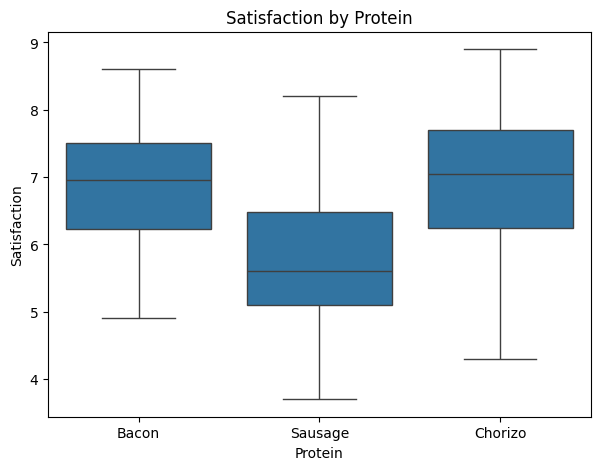

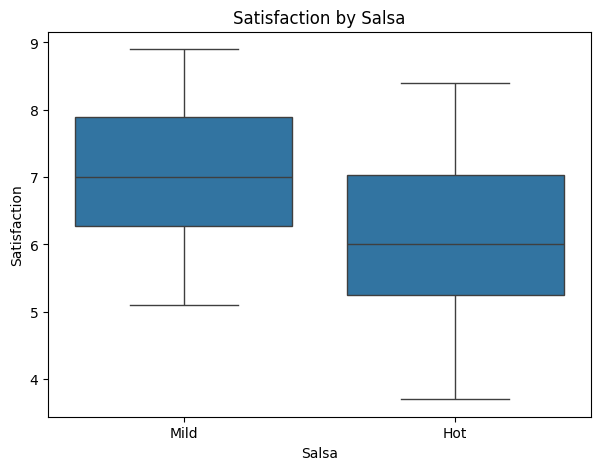

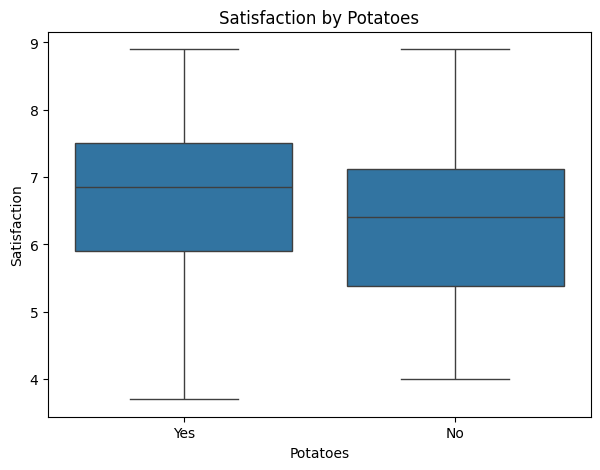

In [2]:
# Boxplots
plt.figure(figsize=(7,5))
sns.boxplot(x="Protein", y="Satisfaction", data=df)
plt.title("Satisfaction by Protein")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Salsa", y="Satisfaction", data=df)
plt.title("Satisfaction by Salsa")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Potatoes", y="Satisfaction", data=df)
plt.title("Satisfaction by Potatoes")
plt.show()


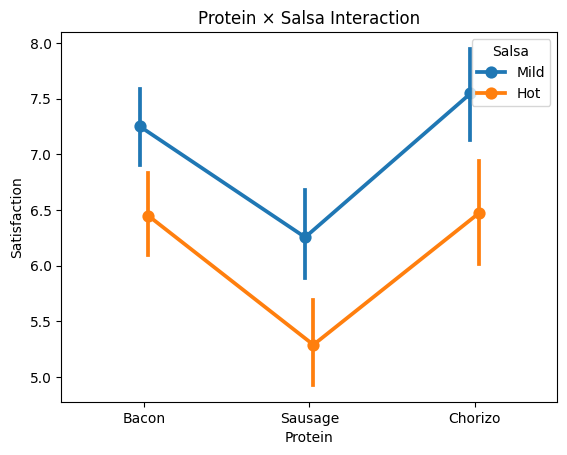

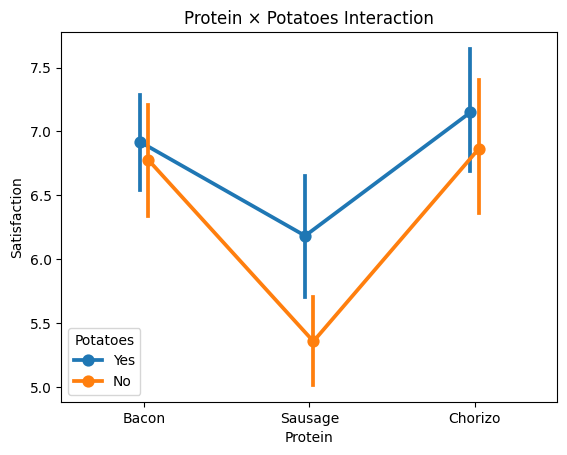

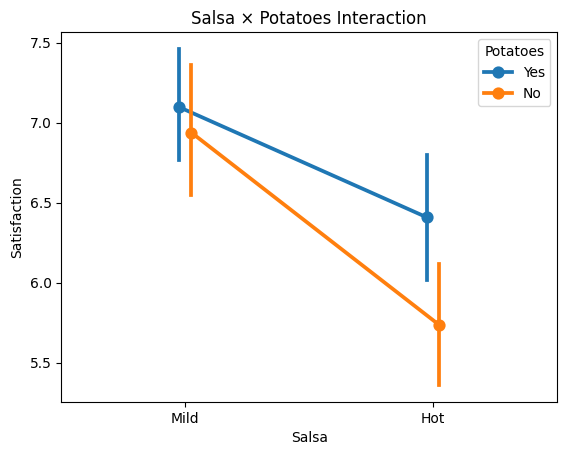

In [3]:
# Interaction plots
sns.pointplot(
    x="Protein",
    y="Satisfaction",
    hue="Salsa",
    data=df,
    dodge=True
)
plt.title("Protein × Salsa Interaction")
plt.show()

sns.pointplot(
    x="Protein",
    y="Satisfaction",
    hue="Potatoes",
    data=df,
    dodge=True
)
plt.title("Protein × Potatoes Interaction")
plt.show()

sns.pointplot(
    x="Salsa",
    y="Satisfaction",
    hue="Potatoes",
    data=df,
    dodge=True
)
plt.title("Salsa × Potatoes Interaction")
plt.show()

Exploratory analysis was performed using summary statistics, boxplots, and interaction plots to examine how satisfaction ratings vary across the ingredient combinations.

The overall mean satisfaction rating was approximately **6.54**, with ratings ranging from **3.7 to 8.9**.

The summary statistics and boxplots show noticeable differences across the protein types. **Chorizo** had the highest average satisfaction rating (mean ≈ **7.01**), followed closely by **Bacon** (mean ≈ **6.85**), while **Sausage** had the lowest average satisfaction rating (mean ≈ **5.77**). The boxplots also show that the distributions for Bacon and Chorizo are generally shifted higher than the distribution for Sausage. This suggests that protein type likely affects customer satisfaction.

For salsa, burritos with **Mild salsa** had noticeably higher satisfaction ratings (mean ≈ **7.02**) compared to **Hot salsa** (mean ≈ **6.07**). The boxplots show that the Mild salsa group is centered at higher satisfaction values overall, suggesting a clear salsa effect.

For potatoes, the difference appears smaller. Burritos with potatoes had a slightly higher average satisfaction rating (mean ≈ **6.75**) than burritos without potatoes (mean ≈ **6.34**), but the boxplots show substantial overlap between the two groups. This suggests that the potatoes effect may be weaker.

The treatment-combination means provide additional support for these patterns. The highest average satisfaction rating was observed for **Chorizo + Mild + No Potatoes** (mean ≈ **7.62**), followed closely by **Chorizo + Mild + Yes Potatoes** (mean ≈ **7.47**). The lowest average satisfaction rating was observed for **Sausage + Hot + No Potatoes** (mean ≈ **4.86**).

The interaction plots were also examined to assess whether the effect of one factor depends on another factor. The **Protein × Salsa** interaction plot shows lines that are mostly parallel, suggesting little evidence of a strong interaction. The **Protein × Potatoes** interaction plot shows slight non-parallel behavior, particularly for Sausage, but the interaction still appears relatively weak overall. The **Salsa × Potatoes** interaction plot shows some non-parallel pattern, suggesting a possible interaction-like effect, although the main salsa effect still appears stronger than the interaction.

Overall, the exploratory analysis provides stronger support for the alternative hypotheses for the main effects of **Protein** and **Salsa**. The evidence for the main effect of **Potatoes** appears weaker, and the interaction effects do not appear especially strong based on the descriptive analysis alone.

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

                            sum_sq     df           F        PR(>F)
Intercept               388.129000    1.0  455.134984  1.589770e-40
Protein                  11.512667    2.0    6.750098  1.728726e-03
Salsa                     6.050000    1.0    7.094463  8.915854e-03
Potatoes                  0.968000    1.0    1.135114  2.890632e-01
Protein:Salsa             0.730333    2.0    0.428208  6.527771e-01
Protein:Potatoes          0.457333    2.0    0.268143  7.653058e-01
Salsa:Potatoes            0.900000    1.0    1.055375  3.065679e-01
Protein:Salsa:Potatoes    0.828167    2.0    0.485570  6.166832e-01
Residual                 92.100000  108.0         NaN           NaN


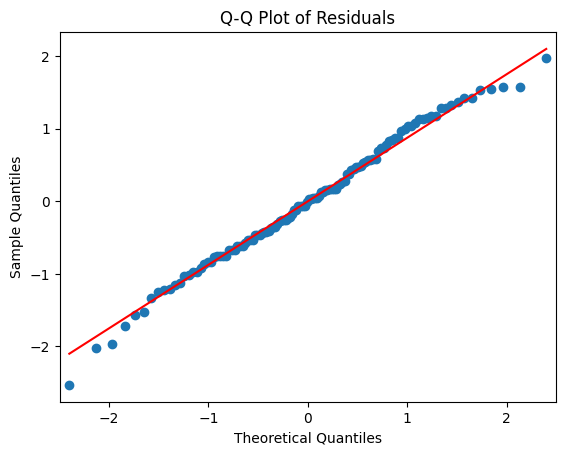

Shapiro-Wilk Statistic: 0.9912132000918904
p-value: 0.6465112757958724


In [4]:
## Question 7 Code ##
import statsmodels.api as sm

from statsmodels.formula.api import ols

import scipy.stats as stats

import matplotlib.pyplot as plt

# Fit full factorial ANOVA model

model = ols(

    'Satisfaction ~ Protein * Salsa * Potatoes',

    data=df

).fit()

# Type III ANOVA table

anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

# Residuals

residuals = model.resid

# Q-Q Plot

sm.qqplot(residuals, line='s')

plt.title("Q-Q Plot of Residuals")

plt.show()

# Shapiro-Wilk Test

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Statistic:", shapiro_test.statistic)

print("p-value:", shapiro_test.pvalue)

### Interpretation

A full factorial ANOVA model was fit to the data, including all main effects and interaction terms for Protein, Salsa, and Potatoes.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro-Wilk test.

From the Q-Q plot, most of the residuals lie very close to the reference line throughout the center of the distribution. There are a few observations in the upper and lower tails that deviate somewhat from the line, but the deviations are relatively small and there is no strong systematic pattern or curvature. Overall, the plot suggests that the residuals are approximately normally distributed.

The Shapiro-Wilk test provides a formal assessment of normality. The test produced a p-value of approximately **0.647**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

Overall, both the visual method and the formal testing method suggest that the normality assumption is reasonably satisfied for this ANOVA model.

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

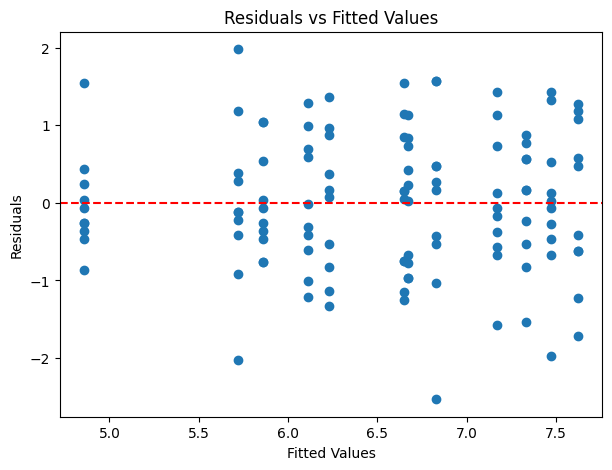

Breusch-Pagan Test Statistic: 8.62394660642261
p-value: 0.656559099121756


In [5]:
## Question 8 Code ##
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuals and fitted values

residuals = model.resid

fitted_values = model.fittedvalues

# Residuals vs Fitted Plot

plt.figure(figsize=(7,5))

plt.scatter(fitted_values, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

# Breusch-Pagan Test

bp_test = het_breuschpagan(residuals, model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])

print("p-value:", bp_test[1])

### Interpretation

The constant variance assumption was assessed using both a residuals versus fitted values plot and the Breusch-Pagan test.

From the residuals versus fitted values plot, the residuals appear to be randomly scattered around zero across the range of fitted values. There is no clear funnel shape, curved pattern, or other systematic structure in the plot. The spread of the residuals appears reasonably similar across the fitted values, although there is some natural variability and a few more extreme residuals.

The Breusch-Pagan test provides a formal assessment of constant variance. The test produced a p-value of approximately **0.657**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

Overall, both the visual method and the formal testing method suggest that the constant variance assumption is reasonably satisfied for this ANOVA model.

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

## Question 9 Interpretation

The full factorial ANOVA model produced the following results:

- **Protein:** \(F = 6.750,\; p = 0.0017\)
- **Salsa:** \(F = 7.094,\; p = 0.0089\)
- **Potatoes:** \(F = 1.135,\; p = 0.2891\)
- **Protein × Salsa:** \(F = 0.428,\; p = 0.6528\)
- **Protein × Potatoes:** \(F = 0.268,\; p = 0.7653\)
- **Salsa × Potatoes:** \(F = 1.055,\; p = 0.3066\)
- **Protein × Salsa × Potatoes:** \(F = 0.486,\; p = 0.6167\)

Based on these results, the main effects of **Protein** and **Salsa** are statistically significant at the 0.05 level. This suggests that different protein types and salsa types are associated with differences in mean customer satisfaction ratings.

The main effect of **Potatoes** is not statistically significant, indicating that there is not strong evidence that adding potatoes changes satisfaction ratings on average.

For the interaction effects, none of the two-way or three-way interactions are statistically significant. This suggests that the effect of one factor does not appear to depend strongly on the levels of the other factors. In other words, the factors appear to act mostly independently in their effects on satisfaction ratings.

Overall, the results provide stronger support for the alternative hypotheses for the main effects of **Protein** and **Salsa**, while the results support the null hypotheses for **Potatoes** and all interaction effects.

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [6]:
## Question 10 Code ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD for Protein

tukey_protein = pairwise_tukeyhsd(

    endog=df["Satisfaction"],

    groups=df["Protein"],

    alpha=0.05

)

print(tukey_protein)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo   0.1575 0.7824  -0.402   0.717  False
  Bacon Sausage  -1.0775    0.0  -1.637  -0.518   True
Chorizo Sausage   -1.235    0.0 -1.7945 -0.6755   True
------------------------------------------------------


### Interpretation

Since the main effects of **Protein** and **Salsa** were found to be statistically significant, post-hoc analysis was considered for those factors. However, post-hoc testing is mainly needed for factors with more than two levels.

The factor **Protein** has three levels (Bacon, Sausage, and Chorizo), so a Tukey HSD post-hoc test was performed to determine which protein groups differ significantly from one another.

The Tukey HSD results showed that:

- **Bacon** produced significantly higher satisfaction ratings than **Sausage** (\(p < 0.001\)).
- **Chorizo** also produced significantly higher satisfaction ratings than **Sausage** (\(p < 0.001\)).
- The difference between **Bacon** and **Chorizo** was not statistically significant (\(p = 0.782\)).

These results suggest that both Bacon and Chorizo are preferred over Sausage, while Bacon and Chorizo perform similarly overall.

Although **Salsa** was statistically significant, post-hoc testing was not necessary because Salsa only has two levels (Hot and Mild). The ANOVA result itself already fully captures the difference between those two groups. The results showed that Mild salsa produced significantly higher satisfaction ratings than Hot salsa.

Post-hoc testing was not conducted for Potatoes or any interaction effects because those effects were not statistically significant in the ANOVA model. When an overall effect is not statistically significant, additional pairwise comparisons are generally not appropriate.

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [7]:
## Question 11 Code ##
# Partial eta squared for main effects

ss_error = anova_table.loc["Residual", "sum_sq"]

partial_eta_squared = {}

for effect in ["Protein", "Salsa", "Potatoes"]:

    ss_effect = anova_table.loc[effect, "sum_sq"]

    partial_eta_squared[effect] = ss_effect / (ss_effect + ss_error)

print(partial_eta_squared)

{'Protein': np.float64(0.11111254093772366), 'Salsa': np.float64(0.06164034640855815), 'Potatoes': np.float64(0.01040099712038525)}


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

The results of this experiment suggest that both **Protein** and **Salsa** have meaningful effects on customer satisfaction ratings, while the effect of **Potatoes** appears to be much smaller. In particular, burritos made with **Chorizo** or **Bacon** generally received higher ratings than burritos made with **Sausage**, and burritos with **Mild salsa** consistently received higher satisfaction ratings than those with **Hot salsa**.

The ANOVA results showed statistically significant main effects for Protein and Salsa, while none of the interaction effects were statistically significant. This suggests that the factors mostly act independently in their effects on customer satisfaction. The partial $\eta^2$ values also indicated that Protein was the most important factor, followed by Salsa, while Potatoes explained very little variability in ratings.

The treatment-combination means further support these findings. The highest average satisfaction rating was observed for:

- **Chorizo + Mild + No Potatoes** (mean ≈ 7.62)

Other highly rated combinations included:

- **Chorizo + Mild + Yes Potatoes** (mean ≈ 7.47)

- **Bacon + Mild + No Potatoes** (mean ≈ 7.33)

- **Bacon + Mild + Yes Potatoes** (mean ≈ 7.17)

Based on these results, the burrito combinations that should most likely be included regularly on the menu are those using:

- **Chorizo or Bacon**

- **Mild salsa**

- Potatoes may be optional since their effect appears relatively small

There are several limitations to this experiment. The participants may not fully represent the broader customer population, and individual food preferences could influence ratings. The experiment also only considered three ingredients, while other factors such as cheese, tortilla type, portion size, or freshness may also affect satisfaction. In addition, customer ratings are subjective and may vary depending on hunger level, spice tolerance, or prior food experiences.

For future research, a larger and more diverse sample of participants could be used to improve generalizability. Additional ingredient factors could also be studied, and repeated experiments across different locations or times could help determine whether the results remain consistent across customer groups.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

The objective of this experiment is to determine how truck location, timing, and marketing strategy affect daily sales for Buster’s Breakfast Burritos, and to identify which combination of factors appears to maximize sales revenue.

2. Specify the outcome variable and how it is measured.

The outcome variable is **daily sales amount**.

It is a **quantitative, continuous variable** measured in **dollars**, representing the total sales revenue earned during each truck setup.

3. Specify the independent variables. What lurking variables may be present?

The independent variables are:

- **Location** — categorical nominal variable  

  - Brewery

  - University

- **Timing** — categorical nominal variable  

  - Weekday

  - Weekend

- **Marketing** — categorical nominal variable  

  - Independent

  - Partnership

Some possible lurking variables include:

- weather conditions  

- local events or festivals  

- competing food vendors nearby  

- customer traffic volume  

- economic conditions  

- social media exposure  

- menu item availability  

- differences in setup location quality  

- time of day  

- customer demographics

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

A fractional factorial design is appropriate here because the goal is to study several factors while reducing the amount of time, cost, and resources required to conduct the experiment.

A full \(2^3\) factorial design would require all 8 treatment combinations. Instead, the \(2^{3-1}\) fractional factorial design uses only half of the runs, reducing the design to 4 treatment combinations while still allowing the main effects to be studied.

The main advantage of using a fractional design is efficiency. Fewer runs are needed, which saves time, labor, and operating costs while still providing useful information about the factors affecting sales.

The main disadvantage is that some effects become aliased. In this design, the main effects are confounded with two-way interactions, meaning that the observed effects cannot be interpreted as completely separate effects. As a result, some information is lost compared to a full factorial design.


5. State the sets of null and alternative hypotheses for this experiment.

Let:

- $\mu_{A-}, \mu_{A+}$ = mean sales for Location (Brewery, University)  
- $\mu_{B-}, \mu_{B+}$ = mean sales for Timing (Weekday, Weekend)  
- $\mu_{C-}, \mu_{C+}$ = mean sales for Marketing (Independent, Partnership)  

We test for the main effects in the fractional factorial design.

### Main effect of Location (A)

$$
H_0: \mu_{A-} = \mu_{A+}
$$

$$
H_A: \mu_{A-} \ne \mu_{A+}
$$

---

### Main effect of Timing (B)

$$
H_0: \mu_{B-} = \mu_{B+}
$$

$$
H_A: \mu_{B-} \ne \mu_{B+}
$$

---

### Main effect of Marketing (C)

$$
H_0: \mu_{C-} = \mu_{C+}
$$

$$
H_A: \mu_{C-} \ne \mu_{C+}
$$

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [14]:
## Question 6 Code ##
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

# Load full dataset

df_full = pd.read_excel("Busters Burrito Sales.xlsx")

# Keep only the fractional factorial runs

df = df_full[

    ((df_full["Location"] == "Brewery") & (df_full["Timing"] == "Weekday") & (df_full["Marketing"] == "Independent")) |

    ((df_full["Location"] == "University") & (df_full["Timing"] == "Weekday") & (df_full["Marketing"] == "Partnership")) |

    ((df_full["Location"] == "Brewery") & (df_full["Timing"] == "Weekend") & (df_full["Marketing"] == "Partnership")) |

    ((df_full["Location"] == "University") & (df_full["Timing"] == "Weekend") & (df_full["Marketing"] == "Independent"))

].copy()

# Overall summary

print(df["Sales"].describe())

# Summary by factors

print("\nSummary by Location")

print(df.groupby("Location")["Sales"].describe())

print("\nSummary by Timing")

print(df.groupby("Timing")["Sales"].describe())

print("\nSummary by Marketing")

print(df.groupby("Marketing")["Sales"].describe())

# Mean sales by treatment combination

print("\nMean Sales by Treatment Combination")

print(

    df.groupby(["Location","Timing","Marketing"])["Sales"].mean()

)

count      12.000000
mean     1025.208333
std       265.301381
min       728.440000
25%       814.472500
50%       931.200000
75%      1165.292500
max      1492.710000
Name: Sales, dtype: float64

Summary by Location
            count         mean         std     min       25%       50%  \
Location                                                                 
Brewery       6.0  1114.268333  342.245452  728.44  824.5575  1124.120   
University    6.0   936.148333  136.669746  813.40  818.4850   898.205   

                  75%      max  
Location                        
Brewery     1399.6675  1492.71  
University  1058.8350  1102.79  

Summary by Timing
         count         mean         std     min        25%       50%  \
Timing                                                                 
Weekday    6.0   813.748333   53.596984  728.44   804.0475   814.115   
Weekend    6.0  1236.668333  211.322448  966.96  1092.7925  1227.795   

               75%      max  
Timing          

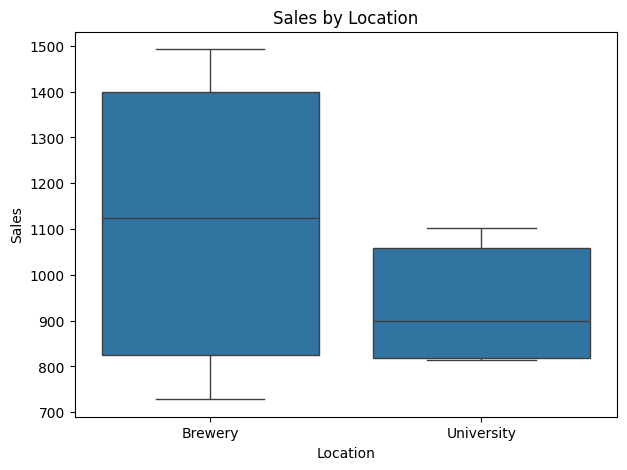

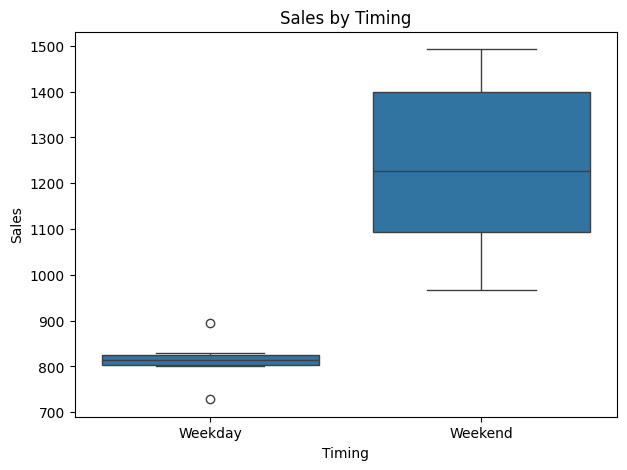

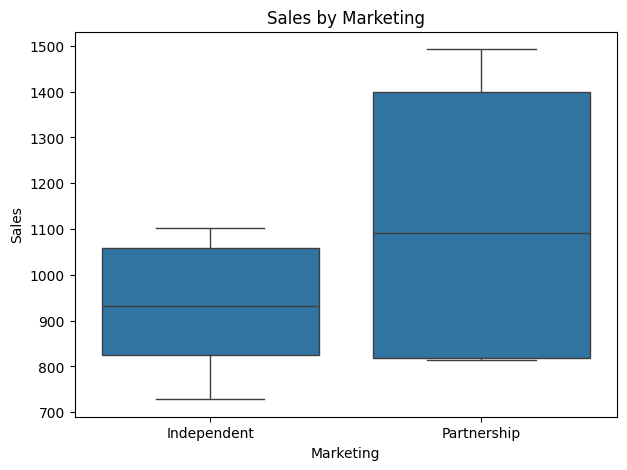

In [15]:
# Boxplots

plt.figure(figsize=(7,5))

sns.boxplot(x="Location", y="Sales", data=df)

plt.title("Sales by Location")

plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(x="Timing", y="Sales", data=df)

plt.title("Sales by Timing")

plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(x="Marketing", y="Sales", data=df)

plt.title("Sales by Marketing")

plt.show()

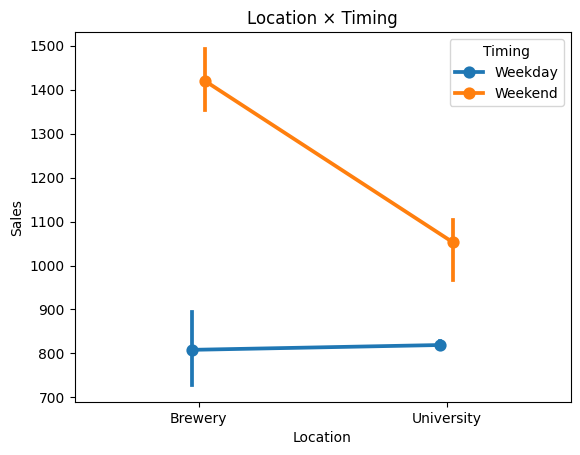

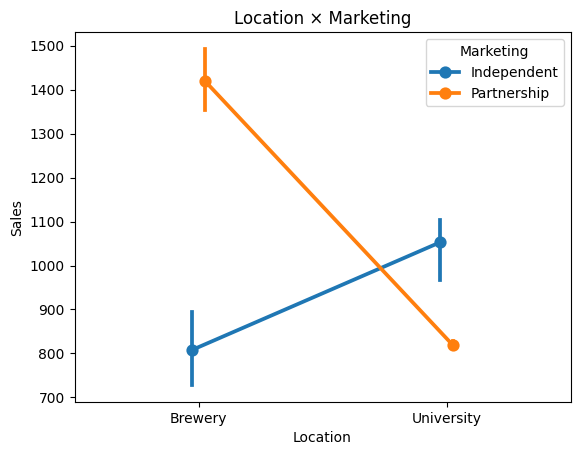

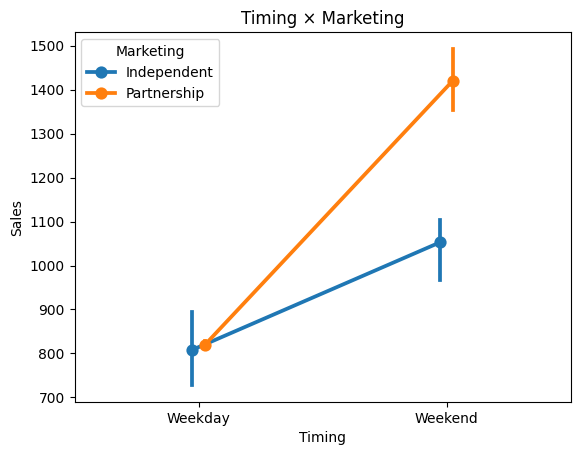

In [16]:
# Interaction plots

sns.pointplot(

    x="Location",

    y="Sales",

    hue="Timing",

    data=df,

    dodge=True

)

plt.title("Location × Timing")

plt.show()

sns.pointplot(

    x="Location",

    y="Sales",

    hue="Marketing",

    data=df,

    dodge=True

)

plt.title("Location × Marketing")

plt.show()

sns.pointplot(

    x="Timing",

    y="Sales",

    hue="Marketing",

    data=df,

    dodge=True

)

plt.title("Timing × Marketing")

plt.show()

### Interpretation

Exploratory analysis was performed using summary statistics, boxplots, and interaction plots to examine how sales vary across the different treatment combinations.

The overall mean sales amount was approximately **\$1025.21**, with sales ranging from about **\$728.44** to **\$1492.71**.

The summary statistics and boxplots show noticeable differences across the factor levels. Sales were higher on average at the **Brewery** location (mean ≈ **\$1114.27**) compared to the **University** location (mean ≈ **\$936.15**). The Brewery condition also showed substantially greater variability, with sales ranging from relatively low values to the highest observed sales overall. In contrast, University sales were more consistent but generally lower.

The largest difference appears for **Timing**. Weekend sales (mean ≈ **\$1236.67**) were much higher than weekday sales (mean ≈ **\$813.75**). The boxplots show strong separation between weekday and weekend sales, with weekend sales consistently shifted upward. This suggests that timing may be the strongest factor affecting sales.

For **Marketing**, partnership marketing produced higher average sales (mean ≈ **\$1119.75**) than independent marketing (mean ≈ **\$930.67**). However, partnership marketing also showed greater variability, while independent marketing produced more moderate and consistent sales values.

The treatment-combination means provide additional support for these patterns. The highest average sales were observed for:

- **Brewery + Weekend + Partnership** (mean ≈ **\$1420.27**)

while the lowest average sales were observed for:

- **Brewery + Weekday + Independent** (mean ≈ **\$808.27**)

The interaction plots were also examined to assess whether the effect of one factor depends on another factor. The **Location × Timing** plot shows a strong non-parallel pattern, where Brewery sales increase substantially on weekends while University sales increase more moderately. The **Location × Marketing** plot shows crossing lines, suggesting that partnership marketing performs especially well at Brewery locations, while independent marketing performs relatively better at University locations. The **Timing × Marketing** plot shows that partnership marketing leads to a much larger increase in sales on weekends compared to weekdays.

Overall, the interaction plots show strong interaction-like patterns. However, because this is a \(2^{3-1}\) fractional factorial design with defining relation \(I = ABC\), the main effects are aliased with two-way interactions. Therefore, these patterns may reflect main effects, interaction effects, or a combination of both, and should be interpreted cautiously.

Overall, the exploratory analysis provides strong support for the alternative hypotheses, particularly for the effects of **Timing** and **Marketing**. The results also suggest that **Location** may influence sales, although the timing effect appears visually strongest.

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?


For the \(2^{3-1}\) fractional factorial design, the defining relation is:

$$
I = ABC
$$

To determine the aliasing structure, multiply both sides of the defining relation by each effect.

### Main Effect Aliases

For factor \(A\):

$$
A = A(ABC) = BC
$$

So:

$$
A = BC
$$

For factor \(B\):

$$
B = B(ABC) = AC
$$

So:

$$
B = AC
$$

For factor \(C\):

$$
C = C(ABC) = AB
$$

So:

$$
C = AB
$$

---

### Interaction Aliases

Similarly:

$$
AB = C
$$

$$
AC = B
$$

$$
BC = A
$$

and

$$
ABC = I
$$

---

### Complete Aliasing Structure

$$
A = BC
$$

$$
B = AC
$$

$$
C = AB
$$

---

### Interpretation

This aliasing structure means that each main effect is confounded with a two-way interaction effect.

Specifically:

- The observed effect for **Location (A)** cannot be separated from the **Timing × Marketing (BC)** interaction.
- The observed effect for **Timing (B)** cannot be separated from the **Location × Marketing (AC)** interaction.
- The observed effect for **Marketing (C)** cannot be separated from the **Location × Timing (AB)** interaction.

As a result, if a main effect appears large or statistically significant, it is not possible to determine whether the effect is truly caused by the main effect itself, the aliased interaction effect, or a combination of both.

This is one of the main disadvantages of fractional factorial designs. The design is more efficient because it requires fewer runs, but some information is lost due to aliasing between effects.

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

                    sum_sq   df           F        PR(>F)
Intercept     1.959901e+06  1.0  445.192945  2.674085e-08
C(Location)   9.518020e+04  1.0   21.620251  1.645197e-03
C(Timing)     5.365840e+05  1.0  121.885432  4.036144e-06
C(Marketing)  1.072500e+05  1.0   24.361904  1.141109e-03
Residual      3.521891e+04  8.0         NaN           NaN


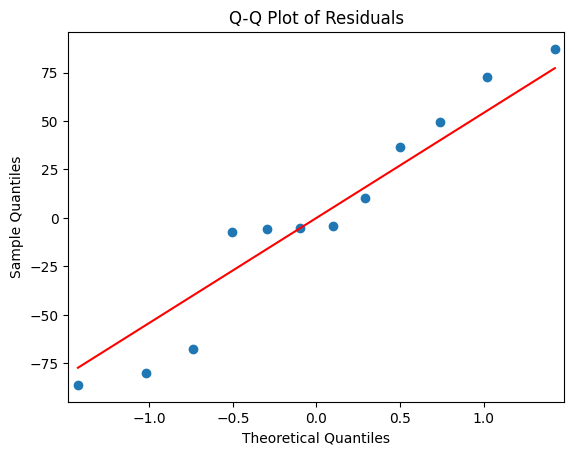

Shapiro-Wilk Statistic: 0.9346876759453925
p-value: 0.4324533858026397


In [17]:
## Question 8 Code ##
import statsmodels.api as sm

from statsmodels.formula.api import ols

import scipy.stats as stats

import matplotlib.pyplot as plt

# Fit ANOVA model with main effects only

# (main effects are aliased with two-way interactions)

model = ols(

    'Sales ~ C(Location) + C(Timing) + C(Marketing)',

    data=df

).fit()

# Type III ANOVA table

anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

# Residuals

residuals = model.resid

# Q-Q Plot

sm.qqplot(residuals, line='s')

plt.title("Q-Q Plot of Residuals")

plt.show()

# Shapiro-Wilk Test

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Statistic:", shapiro_test.statistic)

print("p-value:", shapiro_test.pvalue)

### Interpretation

An ANOVA model including the main effects of Location, Timing, and Marketing was fit to the data. Because this is a \(2^{3-1}\) fractional factorial design, the main effects are aliased with two-way interactions, so the estimated effects represent combinations of main and interaction effects.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro-Wilk test.

From the Q-Q plot, the residuals generally follow the reference line reasonably well through the center of the distribution. However, there are some noticeable deviations in the lower tail, where a few observations fall below the line, and some moderate deviations in the upper tail as well. These deviations are not extreme, but they are more noticeable because the sample size is very small (\(n=12\)), so each observation has a larger influence on the overall pattern of the plot.

The Shapiro-Wilk test produced a p-value of approximately **0.432**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

Overall, although the Q-Q plot shows some mild deviations in the tails, both the visual method and the formal testing method suggest that the normality assumption is reasonably satisfied for this ANOVA model, especially given the small sample size.

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

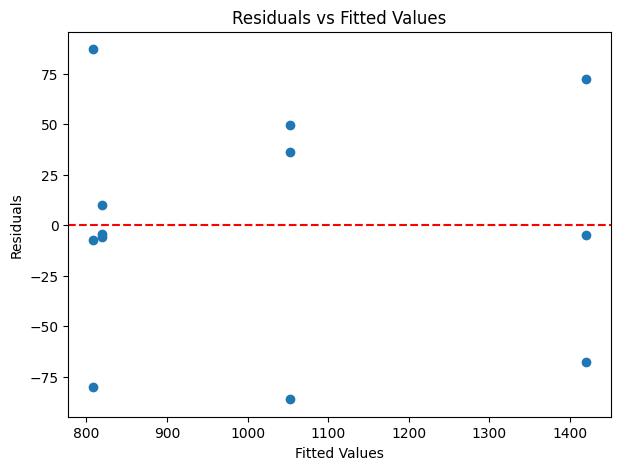

Breusch-Pagan Test Statistic: 4.1034964203964
p-value: 0.2505030774019734


In [18]:
## Question 9 Code ##
from statsmodels.stats.diagnostic import het_breuschpagan

import matplotlib.pyplot as plt

# Residuals and fitted values

residuals = model.resid

fitted_values = model.fittedvalues

# Residuals vs Fitted Plot

plt.figure(figsize=(7,5))

plt.scatter(fitted_values, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

# Breusch-Pagan Test

bp_test = het_breuschpagan(residuals, model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])

print("p-value:", bp_test[1])

### Interpretation

The constant variance assumption was assessed using both a residuals versus fitted values plot and the Breusch-Pagan test.

From the residuals versus fitted values plot, the residuals appear to be scattered around zero without a strong systematic pattern. The spread of the residuals is somewhat variable across the fitted values, but there is no clear funnel shape or consistent increase/decrease in variability. Because the sample size is very small (\(n=12\)), the residual plot contains only a few points at each fitted-value level, which makes the pattern appear more uneven than it would in a larger dataset.

At lower fitted values (around \$800), the residuals include both positive and negative values with a fairly wide spread. At middle fitted values (around \$1050), the residuals are also spread on both sides of zero. At the highest fitted values (around \$1420), the residuals again show both positive and negative values. Overall, the variability does not appear to systematically increase or decrease across the fitted values.

The Breusch-Pagan test produced a p-value of approximately **0.251**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

Overall, although the residual spread is somewhat uneven due to the small sample size, both the visual method and the formal testing method suggest that the constant variance assumption is reasonably satisfied for this ANOVA model.

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit appropriate ANOVA model for fractional factorial design
# Main effects only because main effects are aliased with two-way interactions
model = ols(
    "Sales ~ C(Location) + C(Timing) + C(Marketing)",
    data=df
).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=3)
print(anova_table)

                    sum_sq   df           F        PR(>F)
Intercept     1.959901e+06  1.0  445.192945  2.674085e-08
C(Location)   9.518020e+04  1.0   21.620251  1.645197e-03
C(Timing)     5.365840e+05  1.0  121.885432  4.036144e-06
C(Marketing)  1.072500e+05  1.0   24.361904  1.141109e-03
Residual      3.521891e+04  8.0         NaN           NaN


The ANOVA model produced the following results:

- **Location:** \(F = 21.620,\; p = 0.00165\)
- **Timing:** \(F = 121.885,\; p = 0.000004\)
- **Marketing:** \(F = 24.362,\; p = 0.00114\)

Based on these results, all three main effects are statistically significant at the 0.05 level.

The effect of **Location** is statistically significant, suggesting that average sales differ between Brewery and University locations. The descriptive analysis showed that Brewery locations generally produced higher sales than University locations.

The effect of **Timing** is highly statistically significant and appears to be the strongest effect in the model. This suggests that average sales differ substantially between weekdays and weekends. The summary statistics and boxplots showed that weekend sales were much higher overall than weekday sales.

The effect of **Marketing** is also statistically significant, suggesting that partnership marketing and independent marketing produce different average sales levels. The exploratory analysis showed that partnership marketing generally resulted in higher sales.

Because this is a \(2^{3-1}\) fractional factorial design with defining relation \(I = ABC\), the main effects are aliased with two-way interactions:

$$
A = BC,\quad B = AC,\quad C = AB
$$

Therefore, the significant effects cannot be interpreted as purely main effects alone. Each observed effect may reflect a main effect, an aliased two-way interaction effect, or a combination of both.

Overall, the ANOVA results provide stronger support for the alternative hypotheses than the null hypotheses. In particular, the results suggest that Timing has the strongest influence on sales, followed by Marketing and Location.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [20]:
## Question 11 Code ##
# Calculate main effects manually

# Location effect

location_effect = (

    df[df["Location"] == "University"]["Sales"].mean()

    - df[df["Location"] == "Brewery"]["Sales"].mean()

)

# Timing effect

timing_effect = (

    df[df["Timing"] == "Weekend"]["Sales"].mean()

    - df[df["Timing"] == "Weekday"]["Sales"].mean()

)

# Marketing effect

marketing_effect = (

    df[df["Marketing"] == "Partnership"]["Sales"].mean()

    - df[df["Marketing"] == "Independent"]["Sales"].mean()

)

print("Location Effect (University - Brewery):", location_effect)

print("Timing Effect (Weekend - Weekday):", timing_effect)

print("Marketing Effect (Partnership - Independent):", marketing_effect)

Location Effect (University - Brewery): -178.12
Timing Effect (Weekend - Weekday): 422.91999999999985
Marketing Effect (Partnership - Independent): 189.0766666666667


### Interpretation

The estimated main effects were:

- **Location Effect (University − Brewery):** ≈ **−178.12**
- **Timing Effect (Weekend − Weekday):** ≈ **422.92**
- **Marketing Effect (Partnership − Independent):** ≈ **189.08**

The negative Location effect indicates that University locations produced lower average sales than Brewery locations. On average, sales at University locations were about **\$178 lower** than sales at Brewery locations.

The Timing effect was the largest effect in magnitude. Weekend setups produced average sales that were approximately **\$423 higher** than weekday setups. This suggests that timing has the strongest influence on sales performance.

The Marketing effect was also positive, indicating that partnership marketing increased average sales by approximately **\$189** compared to independent marketing.

Based on the magnitudes of the estimated effects, the effects appear to rank as:

$$
\text{Timing} > \text{Marketing} > \text{Location}
$$

This conclusion is also consistent with the ANOVA results and the exploratory visualizations, where Timing showed the clearest separation in sales values between groups.

However, because this is a fractional factorial design with defining relation

$$
I = ABC
$$

the main effects are aliased with two-way interactions. Therefore, these estimated effects may reflect main effects, interaction effects, or a combination of both.

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [21]:
## Question 12 Code ##
# Partial eta squared for main effects

ss_error = anova_table.loc["Residual", "sum_sq"]

partial_eta_squared = {}

for effect in ["C(Location)", "C(Timing)", "C(Marketing)"]:

    ss_effect = anova_table.loc[effect, "sum_sq"]

    partial_eta_squared[effect] = ss_effect / (ss_effect + ss_error)

print(partial_eta_squared)

{'C(Location)': np.float64(0.7299145080574607), 'C(Timing)': np.float64(0.9384072572673064), 'C(Marketing)': np.float64(0.7527957568566986)}


### Interpretation

The partial $\eta^2$ values were calculated using:

$$
\eta_p^2 = \frac{SS_{\text{effect}}}{SS_{\text{effect}} + SS_{\text{error}}}
$$

The resulting values were:

- **Location:** $\eta_p^2 = 0.730$
- **Timing:** $\eta_p^2 = 0.938$
- **Marketing:** $\eta_p^2 = 0.753$

These results indicate that **Timing** has the largest effect size and explains the greatest proportion of variability in sales. This suggests that whether the truck operates on weekdays or weekends is the most important factor affecting sales performance.

The effect sizes for **Marketing** and **Location** are also large, suggesting that both factors contribute meaningfully to explaining variation in sales.

Based on the partial $\eta^2$ values, the effects appear to rank as:

$$
\text{Timing} > \text{Marketing} > \text{Location}
$$

This ranking is consistent with the ANOVA results, the estimated main effects, and the exploratory visualizations, where Timing showed the strongest separation between groups.

However, because this is a fractional factorial design with defining relation

$$
I = ABC
$$

the main effects are aliased with two-way interactions. Therefore, these large effect sizes may reflect main effects, interaction effects, or a combination of both.

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

### Question 13

Overall, the results suggest that **Timing**, **Marketing**, and **Location** are all important for sales, with **Timing** appearing to have the strongest effect. Weekend setups produced much higher sales than weekday setups, partnership marketing generally performed better than independent marketing, and Brewery locations had higher average sales than University locations.

The highest observed treatment-combination mean was:

- **Brewery + Weekend + Partnership**: mean sales ≈ **$1420.27**

Based on this experiment, the best combination to maximize sales is:

- **Location:** Brewery  
- **Timing:** Weekend  
- **Marketing:** Partnership  

However, because this was a \(2^{3-1}\) fractional factorial design with defining relation \(I = ABC\), the main effects are aliased with two-way interactions. This means the observed effects may be due to the main factors, interaction effects, or a combination of both. So this recommendation should be interpreted as the best-performing observed combination in this experiment, not as a fully separated estimate of each factor’s pure effect.

Some limitations of this experiment are the small sample size, with only 12 total observations after using the fractional design, and the fact that only half of the full \(2^3\) combinations were tested. Sales may also be affected by lurking variables such as weather, local events, customer traffic, nearby competitors, time of day, and social media exposure.

In the future, this experiment could be improved by running the full \(2^3\) factorial design, adding more replications, and testing across more days and locations. This would help separate main effects from interactions and give a more reliable recommendation for maximizing sales.


## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

We can de-alias effects in a fractional factorial design by adding additional experimental runs, such as performing the complementary fraction or expanding the experiment into a full factorial design. This allows the main effects and interaction effects to be estimated separately instead of being confounded together.

De-aliasing is important because aliasing makes it difficult to determine whether an observed effect is caused by a main effect, an interaction effect, or both. Without de-aliasing, interpretations may be incomplete or misleading.

However, de-aliasing is not always feasible because it requires more time, money, resources, and experimental effort. In many real-world situations, researchers use fractional designs specifically to reduce these costs.

---

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

This is good practice because the design of the experiment determines what conclusions can be made from the analysis. Understanding the variables, treatment structure, randomization, replication, possible lurking variables, and assumptions helps ensure that the correct statistical methods are used and that the results are interpreted properly.

It also helps identify possible limitations and sources of bias before performing the analysis. Good experimental design improves the reliability and validity of the conclusions.

---

3. What is the difference between a fixed effect and a random effect?

A fixed effect refers to factor levels that are specifically chosen and are the primary focus of the study. The goal is usually to compare those exact levels. For example, comparing specific burrito ingredients or specific blade designs would involve fixed effects.

A random effect refers to factor levels that are viewed as a random sample from a larger population. The goal is usually to account for variability rather than compare the specific levels themselves. For example, athletes in the mixed effects experiment were treated as a random effect because they represent a larger population of possible athletes.

---

4. What is the most important thing you learned in this class?

The most important thing I learned in this class was how important experimental design is before performing statistical analysis. I learned that factors such as replication, randomization, blocking, factorial structure, and assumptions all affect the quality and interpretation of the final results.

I also learned how interaction effects can change conclusions, why checking assumptions is important, and how different designs such as fractional factorial and mixed effects experiments help balance practical limitations with statistical goals.